In [1]:
import numpy as np

In [2]:
def Auto_pcolormesh(x,y,v,ifself_vmax_vmin='no',selfvmax=None,selfvmin=None,xlabelname=None,ylabelname=None,title=None,shadedcolor=None,valuemodel='+-',xspace=1,yspace=1,labelsize=20,ifcolorbar='yes',ifsave='no',savename=None,dpi=600):
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib as mpl
    import numpy as np
    from matplotlib import ticker

    plt.rcParams['font.sans-serif']=['SimHei'] #正常显示中文
    plt.rcParams['axes.unicode_minus']=False #正常显示正负号
    mpl.rc('axes',lw=2)
    selfcolor1 = ['#000080','#0000CD','#0000FF','#00B2EE','#00FFFF','#FFF68F','#FFFF00','#FFD700','#FF7F00','#FF0000','#FF00FF']
    selfcolor2 = selfcolor1[::-1]
    fig = plt.figure(figsize = (24,16),facecolor = 'white')
    ax = fig.add_subplot(111)
    if ifself_vmax_vmin =='yes' or ifself_vmax_vmin=='both':
        vmax = float(selfvmax)
        vmin = float(selfvmin)
    else:
        vmax = float(np.nanmax(v))
        vmin = float(np.nanmin(v))
    if valuemodel == '+-':
        if shadedcolor == None:
            selfshadedcolor = plt.cm.RdBu_r
        if vmax >= np.abs(vmin):
            c1=ax.pcolormesh(x,y,v,cmap=selfshadedcolor,vmax=vmax,vmin=-vmax)
        else:
            c1=ax.pcolormesh(x,y,v,cmap=selfshadedcolor,vmax=-vmin,vmin=vmin)
    elif valuemodel == '-+':
        if shadedcolor == None:
            selfshadedcolor = plt.cm.RdBu
        if vmax >= np.abs(vmin):
            c1=ax.pcolormesh(x,y,v,cmap=selfshadedcolor,vmax=vmax,vmin=-vmax)
        else:
            c1=ax.pcolormesh(x,y,v,cmap=selfshadedcolor,vmax=-vmin,vmin=vmin)
    elif valuemodel == '+':
        if shadedcolor == None:
            selfshadedcolor = plt.cm.Reds
        c1=ax.pcolormesh(x,y,v,cmap=selfshadedcolor,vmax=vmax,vmin=vmin)
    elif valuemodel == '-':
        if shadedcolor == None:
            selfshadedcolor = plt.cm.Blues
        c1=ax.pcolormesh(x,y,v,cmap=selfshadedcolor,vmax=vmax,vmin=vmin)
    elif valuemodel == '+r':
        if shadedcolor == None:
            selfshadedcolor = plt.cm.Reds_r
        c1=ax.pcolormesh(x,y,v,cmap=selfshadedcolor,vmax=vmax,vmin=vmin)
    elif valuemodel == '-r':
        if shadedcolor == None:
            selfshadedcolor = plt.cm.Blues_r
        c1=ax.pcolormesh(x,y,v,cmap=selfshadedcolor,vmax=vmax,vmin=vmin)
    plt.tick_params(labelsize=labelsize)
    ax.tick_params(axis='x',which='major',width=labelsize/10,length=labelsize/4)
    ax.tick_params(axis='y',which='major',width=labelsize/10,length=labelsize/4)
    plt.xlabel(xlabelname,fontsize = labelsize)
    plt.ylabel(ylabelname,fontsize = labelsize)
    if ifcolorbar == 'yes':
        if (vmax >= 10) or (vmin <= -10) or (vmin >= 10) or (vmax<=-10):
            cb=fig.colorbar(c1,orientation='horizontal',pad = 0.14,fraction = 0.04,aspect = 30,format='%.0f')
        elif (vmax >= 1) or (vmin <= -1) or (vmin >= 1) or (vmax<=-1):
            cb=fig.colorbar(c1,orientation='horizontal',pad = 0.14,fraction = 0.04,aspect = 30,format='%.1f')
        else:
            cb=fig.colorbar(c1,orientation='horizontal',pad = 0.14,fraction = 0.04,aspect = 30,format='%.3f')
        cb.ax.tick_params(length=0,width=0,labelsize=labelsize)
        ticks = np.linspace(vmin, vmax, 5)
        cb.set_ticks(ticks)
    ax.set_title(title,pad = 0.15,fontsize = labelsize)
    plt.show()
    plt.tight_layout()
    if ifsave == 'yes':
        fig.savefig(savename,dpi = dpi)

In [3]:
x=[1,2,3,4,5,6]
x_wrf=[5,10,15,20,25,30]
y=['400','500','600','700','850','925','1000']
y_wrf=['400','500','600','700','850','925']

In [4]:
u_rmse = [
    [6.04810616, 4.9920505,  4.29366457, 3.81879268, 3.16136556, 2.5458364,  1.5365015],
    [5.85219298, 4.88457872, 4.22244418, 3.78128988, 3.11470969, 2.49570189, 1.48968142],
    [5.99334177, 5.03576559, 4.3548503,  3.87648384, 3.22886984, 2.5879846,  1.54994999],
    [6.05402338, 5.05430352, 4.41067347, 4.0097458,  3.31442789, 2.66825988, 1.58667618],
    [6.04511561, 5.05272298, 4.39893692, 3.93362499, 3.25625087, 2.66766143, 1.60191622],
    [6.17151813, 5.15875371, 4.4989133,  4.04628446, 3.4056816,  2.74155693, 1.63820729]
]

v_rmse = [
    [5.31116497, 4.1693653,  3.44718335, 3.08305682, 2.99584593, 2.58740768, 1.48995888],
    [5.12436574, 4.08559769, 3.41627315, 3.05939582, 2.98038388, 2.66462347, 1.52846018],
    [5.00885069, 4.06776322, 3.48015581, 3.17721735, 3.125151,   2.77279617, 1.60245823],
    [5.20287858, 4.13312344, 3.42713729, 3.12628636, 3.16760387, 2.83758367, 1.62459223],
    [5.24198275, 4.18141191, 3.55424582, 3.21570704, 3.21632992, 2.86930159, 1.63220654],
    [5.17718738, 4.10537984, 3.50081241, 3.24584011, 3.26846272, 2.96235004, 1.67567055]
]

w_rmse = [
    [0.02088226, 0.02239808, 0.0235367,  0.02245991, 0.02058031, 0.01591208, 0.00409874],
    [0.02103479, 0.02258691, 0.02371277, 0.02259716, 0.02074844, 0.01612897, 0.00416544],
    [0.02114616, 0.02271826, 0.02384738, 0.02276596, 0.02095449, 0.01634649, 0.00427304],
    [0.02117453, 0.02274068, 0.02385607, 0.02279355, 0.02103516, 0.01648417, 0.00435361],
    [0.021316,   0.02290125, 0.02398233, 0.02288741, 0.02110807, 0.01657864, 0.00440249],
    [0.02137012, 0.02295334, 0.02404875, 0.02294902, 0.02122565, 0.01671554, 0.0044637]
]

u_mae = [
    [4.71859315, 3.9257957,  3.35861865, 2.92793947, 2.39427943, 1.9067452,  1.14456934],
    [4.56902731, 3.83947755, 3.28043028, 2.92075446, 2.37522143, 1.87254349, 1.10931205],
    [4.71153728, 3.99069861, 3.41284491, 3.00187163, 2.469155,   1.9599765,  1.1644103],
    [4.69383056, 3.96946579, 3.4352612,  3.08419137, 2.52015532, 2.00660229, 1.19585666],
    [4.73465316, 3.96879443, 3.42788227, 3.0325574,  2.4831285,  2.00438201, 1.19893992],
    [4.84053753, 4.07091903, 3.48778029, 3.08942732, 2.56827728, 2.05402517, 1.22646338]
]

v_mae = [
    [4.0644474,  3.22296467, 2.66926781, 2.38824688, 2.27620763, 1.9327263,  1.12922504],
    [3.91506756, 3.15688013, 2.64211324, 2.37705931, 2.25806992, 1.9766635,  1.15569088],
    [3.82200859, 3.14348021, 2.70248426, 2.45311386, 2.35911463, 2.05935433, 1.2089386],
    [3.98969301, 3.18351012, 2.66140303, 2.42179176, 2.40434383, 2.11550065, 1.23451572],
    [4.0099064,  3.23952816, 2.77415982, 2.50167239, 2.44360773, 2.14549678, 1.23603032],
    [3.96238537, 3.16772956, 2.70601113, 2.50709661, 2.47974386, 2.20154607, 1.26707041]
]

w_mae = [
    [0.01274998, 0.0134441,  0.01406635, 0.01410948, 0.01390841, 0.01124305, 0.00309643],
    [0.01283791, 0.01351945, 0.01412643, 0.01416275, 0.0140214,  0.01140998, 0.00315204],
    [0.0128455,  0.01356362, 0.01421346, 0.01428926, 0.01417699, 0.01155835, 0.00322902],
    [0.0128553,  0.01353827, 0.01414821, 0.01426289, 0.01420169, 0.01166312, 0.00329317],
    [0.0129019,  0.01361297, 0.01421752, 0.01433132, 0.01427052, 0.01173863, 0.0033319],
    [0.0128583,  0.01357186, 0.01422569, 0.01433534, 0.01432239, 0.01182064, 0.00337148]
]

u_rmspe = [
    [0.09725467, 0.09252423, 0.08727172, 0.08381881, 0.08028357, 0.08353908, 0.08655735],
    [0.09408512, 0.09045356, 0.08571144, 0.0829925,  0.0792728,  0.08272636, 0.08549774],
    [0.09634281, 0.09321225, 0.08839724, 0.08505647, 0.08208266, 0.08544415, 0.0883954],
    [0.09740722, 0.09366009, 0.08953123, 0.08785601, 0.0842966,  0.0881044,  0.09030427],
    [0.09715152, 0.09348024, 0.08923151, 0.08629175, 0.08296321, 0.08816365, 0.0909792],
    [0.09923053, 0.09561624, 0.09142192, 0.08882626, 0.08664235, 0.09043742, 0.09278922]
]

v_rmspe = [
    [0.12593022, 0.10676444, 0.09493348, 0.08752196, 0.07193755, 0.06794447, 0.07127457],
    [0.12157646, 0.10456593, 0.09411012, 0.08688829, 0.07166989, 0.0701665,  0.07340854],
    [0.1187565,  0.10411714, 0.09573097, 0.09014674, 0.07506711, 0.07287938, 0.07663255],
    [0.1234017,  0.10581765, 0.09431518, 0.08894972, 0.0762542,  0.0750123,  0.07827338],
    [0.12429565, 0.10708327, 0.09785284, 0.09135587, 0.07744212, 0.0759127,  0.07908437],
    [0.12283009, 0.10507107, 0.0962831,  0.09221231, 0.07872831, 0.07830502, 0.08101353]
]

w_rmspe = [
    [0.04717769, 0.04274366, 0.04160256, 0.04357815, 0.05018968, 0.06060793, 0.07265793],
    [0.04750014, 0.04308269, 0.04191645, 0.0438391,  0.05060026, 0.06148391, 0.07375855],
    [0.04777263, 0.04336507, 0.0421606,  0.04417063, 0.05110677, 0.06233873, 0.07552624],
    [0.04783991, 0.04339925, 0.0421737,  0.0442271,  0.0513384,  0.06298845, 0.07685362],
    [0.04816133, 0.04370331, 0.04239583, 0.04441611, 0.05152098, 0.06340332, 0.07768642],
    [0.04825224, 0.04379402, 0.04251451, 0.04453365, 0.05180091, 0.06394708, 0.07871983]
]

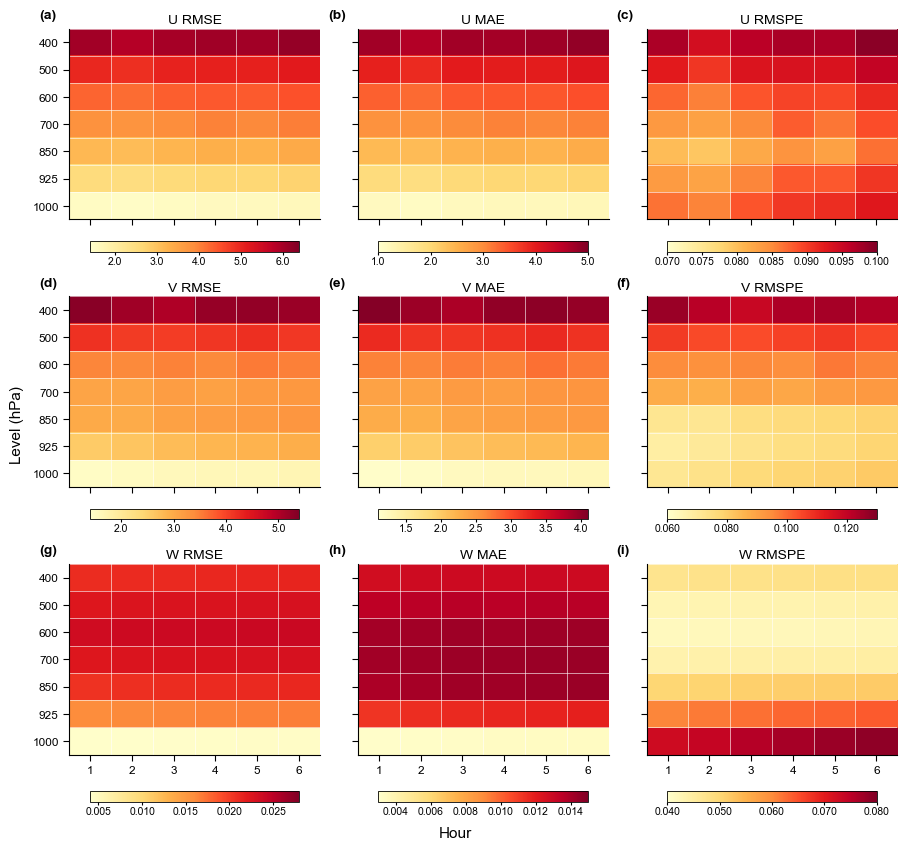

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# =========================
# 1. 数据整理
# =========================
hours = np.array([1, 2, 3, 4, 5, 6])
levels = np.array([400, 500, 600, 700, 850, 925, 1000])

u_rmse_arr  = np.array(u_rmse).T
v_rmse_arr  = np.array(v_rmse).T
w_rmse_arr  = np.array(w_rmse).T

u_mae_arr   = np.array(u_mae).T
v_mae_arr   = np.array(v_mae).T
w_mae_arr   = np.array(w_mae).T

u_rmspe_arr = np.array(u_rmspe).T
v_rmspe_arr = np.array(v_rmspe).T
w_rmspe_arr = np.array(w_rmspe).T

panel_data = [
    (u_rmse_arr,  "U RMSE",  1.4,   6.4,   "%.1f"),
    (u_mae_arr,   "U MAE",   1.0,   5.0,   "%.1f"),
    (u_rmspe_arr, "U RMSPE", 0.070, 0.100, "%.3f"),

    (v_rmse_arr,  "V RMSE",  1.4,   5.4,   "%.1f"),
    (v_mae_arr,   "V MAE",   1.1,   4.1,   "%.1f"),
    (v_rmspe_arr, "V RMSPE", 0.060, 0.130, "%.3f"),

    (w_rmse_arr,  "W RMSE",  0.004, 0.028, "%.3f"),
    (w_mae_arr,   "W MAE",   0.003, 0.015, "%.3f"),
    (w_rmspe_arr, "W RMSPE", 0.040, 0.080, "%.3f"),
]

panel_labels = ["(a)", "(b)", "(c)",
                "(d)", "(e)", "(f)",
                "(g)", "(h)", "(i)"]

# =========================
# 2. 风格
# =========================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.titlesize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
})

fig, axes = plt.subplots(
    3, 3,
    figsize=(9.0, 8.4),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

cmap = plt.cm.YlOrRd

def draw_panel(ax, arr, title, vmin, vmax, fmt, panel_label, row, col):
    im = ax.imshow(
        arr,
        origin="upper",
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    # panel title
    ax.set_title(title, pad=4)

    # panel label
    ax.text(
        -0.12, 1.04, panel_label,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=10, fontweight="bold"
    )

    # tick 位置
    ax.set_xticks(np.arange(len(hours)))
    ax.set_yticks(np.arange(len(levels)))

    # tick label：只保留左列和底行
    if col == 0:
        ax.set_yticklabels(levels)
    else:
        ax.tick_params(axis="y", labelleft=False)

    if row == 2:
        ax.set_xticklabels(hours)
    else:
        ax.tick_params(axis="x", labelbottom=False)

    # 注意：左列和底行仍然保留刻度线
    ax.tick_params(axis="x", which="major", bottom=True, length=4, width=0.8)
    ax.tick_params(axis="y", which="major", left=True, length=4, width=0.8)

    # 网格线
    ax.set_xticks(np.arange(-0.5, len(hours), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(levels), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.6, alpha=0.7)
    ax.tick_params(which="minor", bottom=False, left=False)

    # 去掉多余边框
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # 每个 panel 单独 colorbar
    cb = fig.colorbar(
        im, ax=ax,
        orientation="horizontal",
        fraction=0.055,
        pad=0.08
    )
    cb.ax.xaxis.set_major_formatter(FormatStrFormatter(fmt))
    cb.ax.tick_params(labelsize=7.5, length=2, pad=1)
    cb.outline.set_linewidth(0.6)

# =========================
# 3. 绘图
# =========================
for i, ax in enumerate(axes.flat):
    arr, title, vmin, vmax, fmt = panel_data[i]
    row, col = divmod(i, 3)
    draw_panel(ax, arr, title, vmin, vmax, fmt, panel_labels[i], row, col)

# 整张图共享坐标轴标题
fig.supxlabel("Hour", fontsize=11)
fig.supylabel("Level (hPa)", fontsize=11)

plt.show()

# 保存
# fig.savefig("Fig3_revised_shared_axes_corrected.png", dpi=600, bbox_inches="tight")

In [21]:
print(np.max(u_rmse),np.min(u_rmse))
print(np.max(v_rmse),np.min(v_rmse))
print(np.max(w_rmse),np.min(w_rmse))

6.17151813 1.48968142
5.31116497 1.48995888
0.02404875 0.00409874


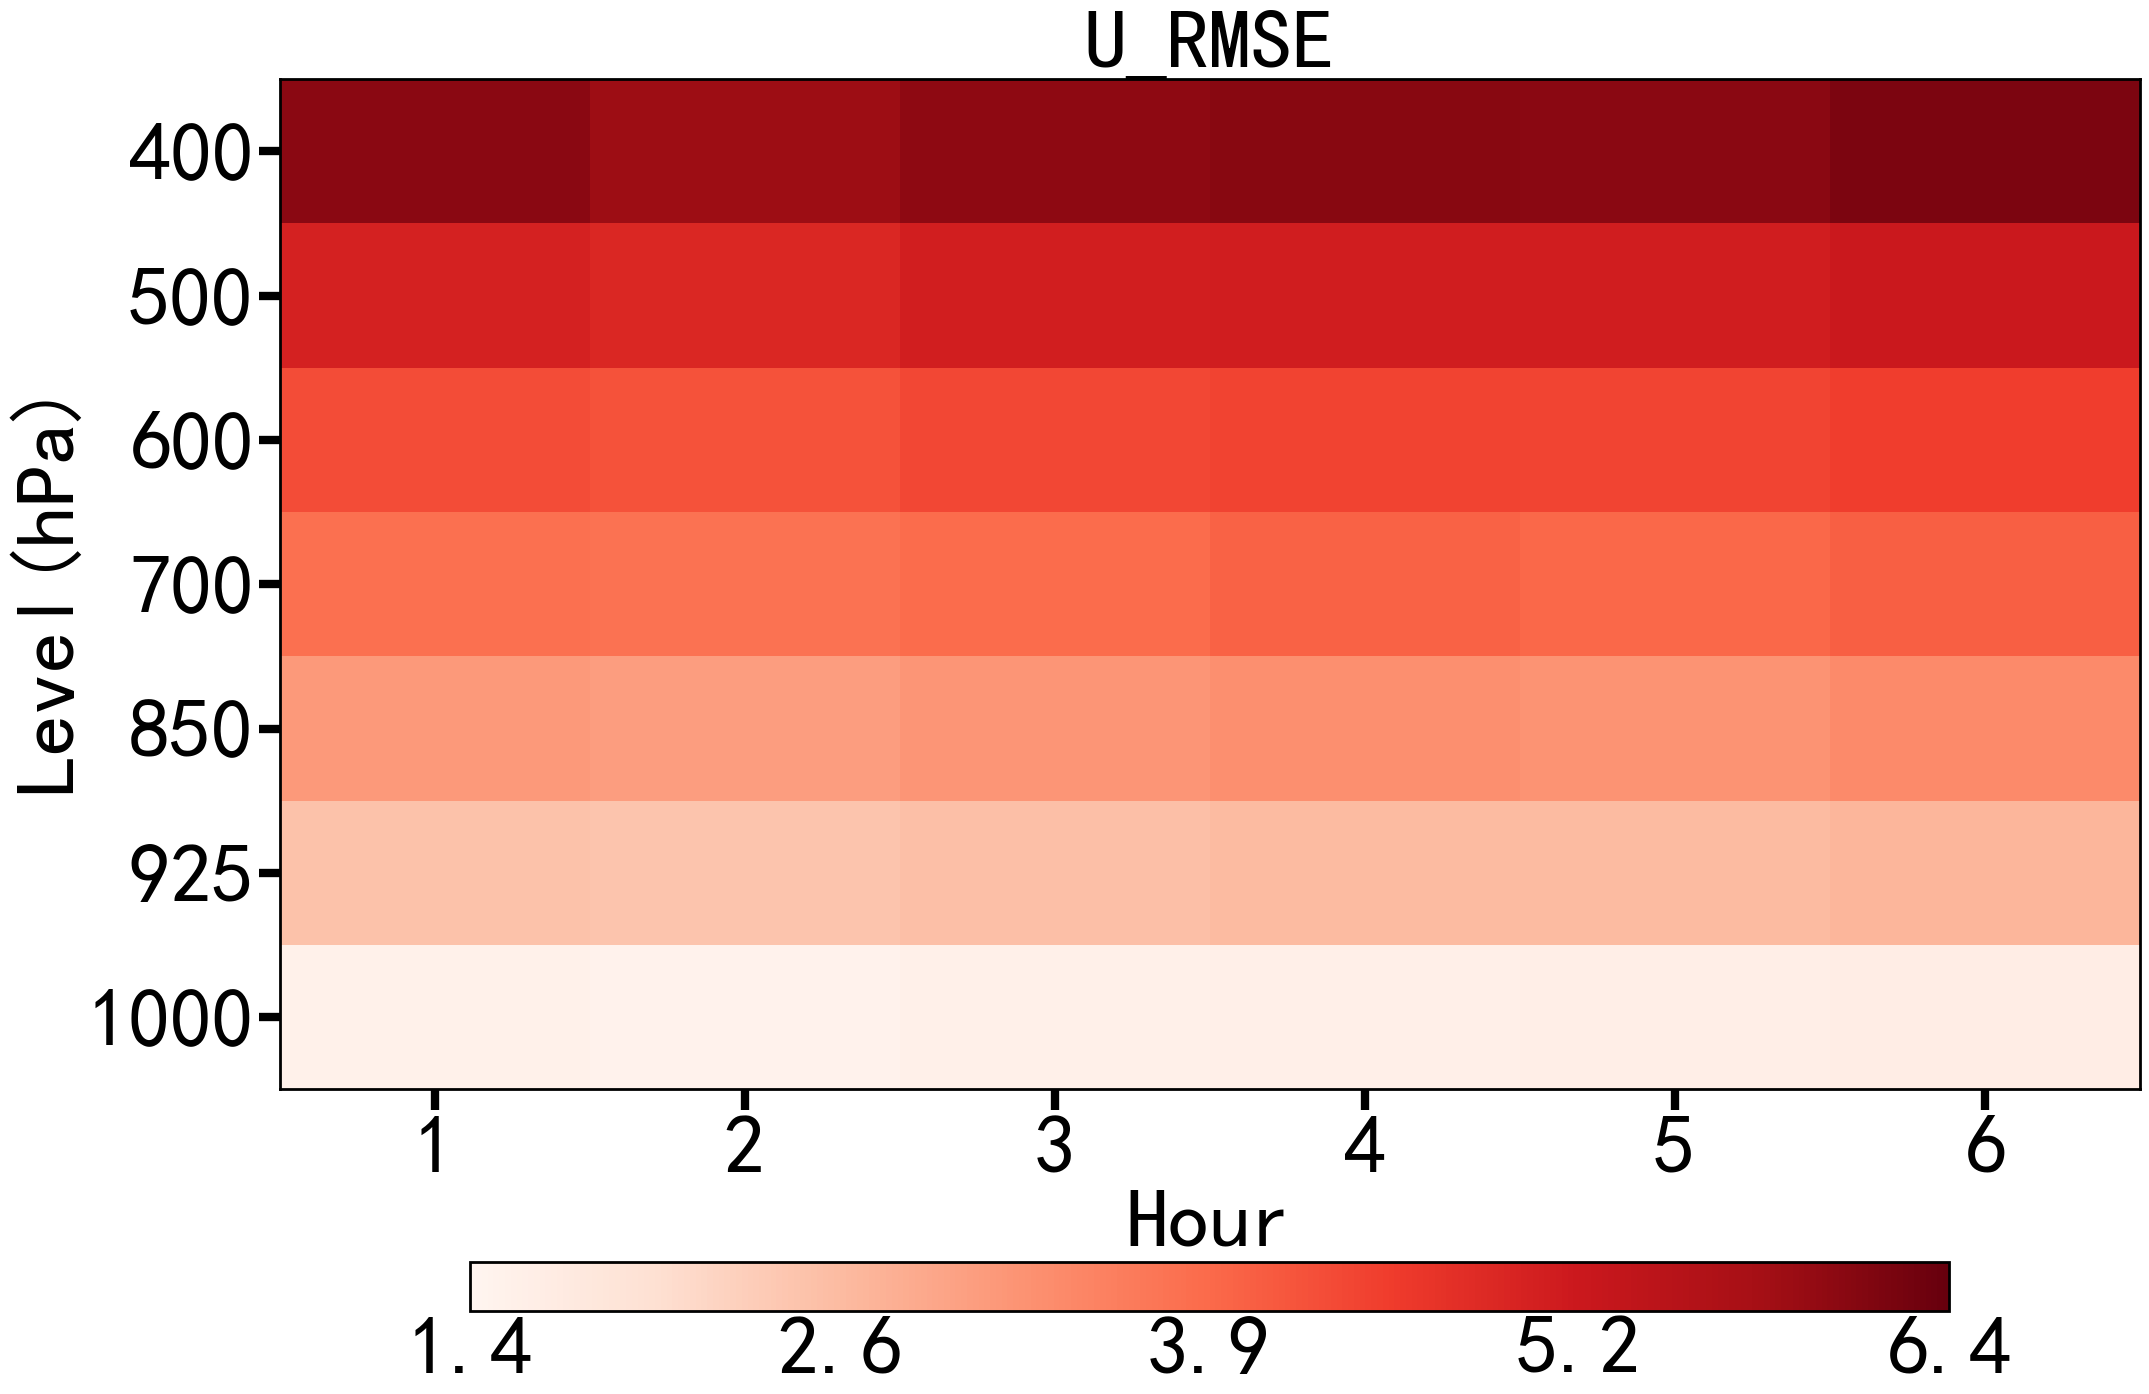

<Figure size 640x480 with 0 Axes>

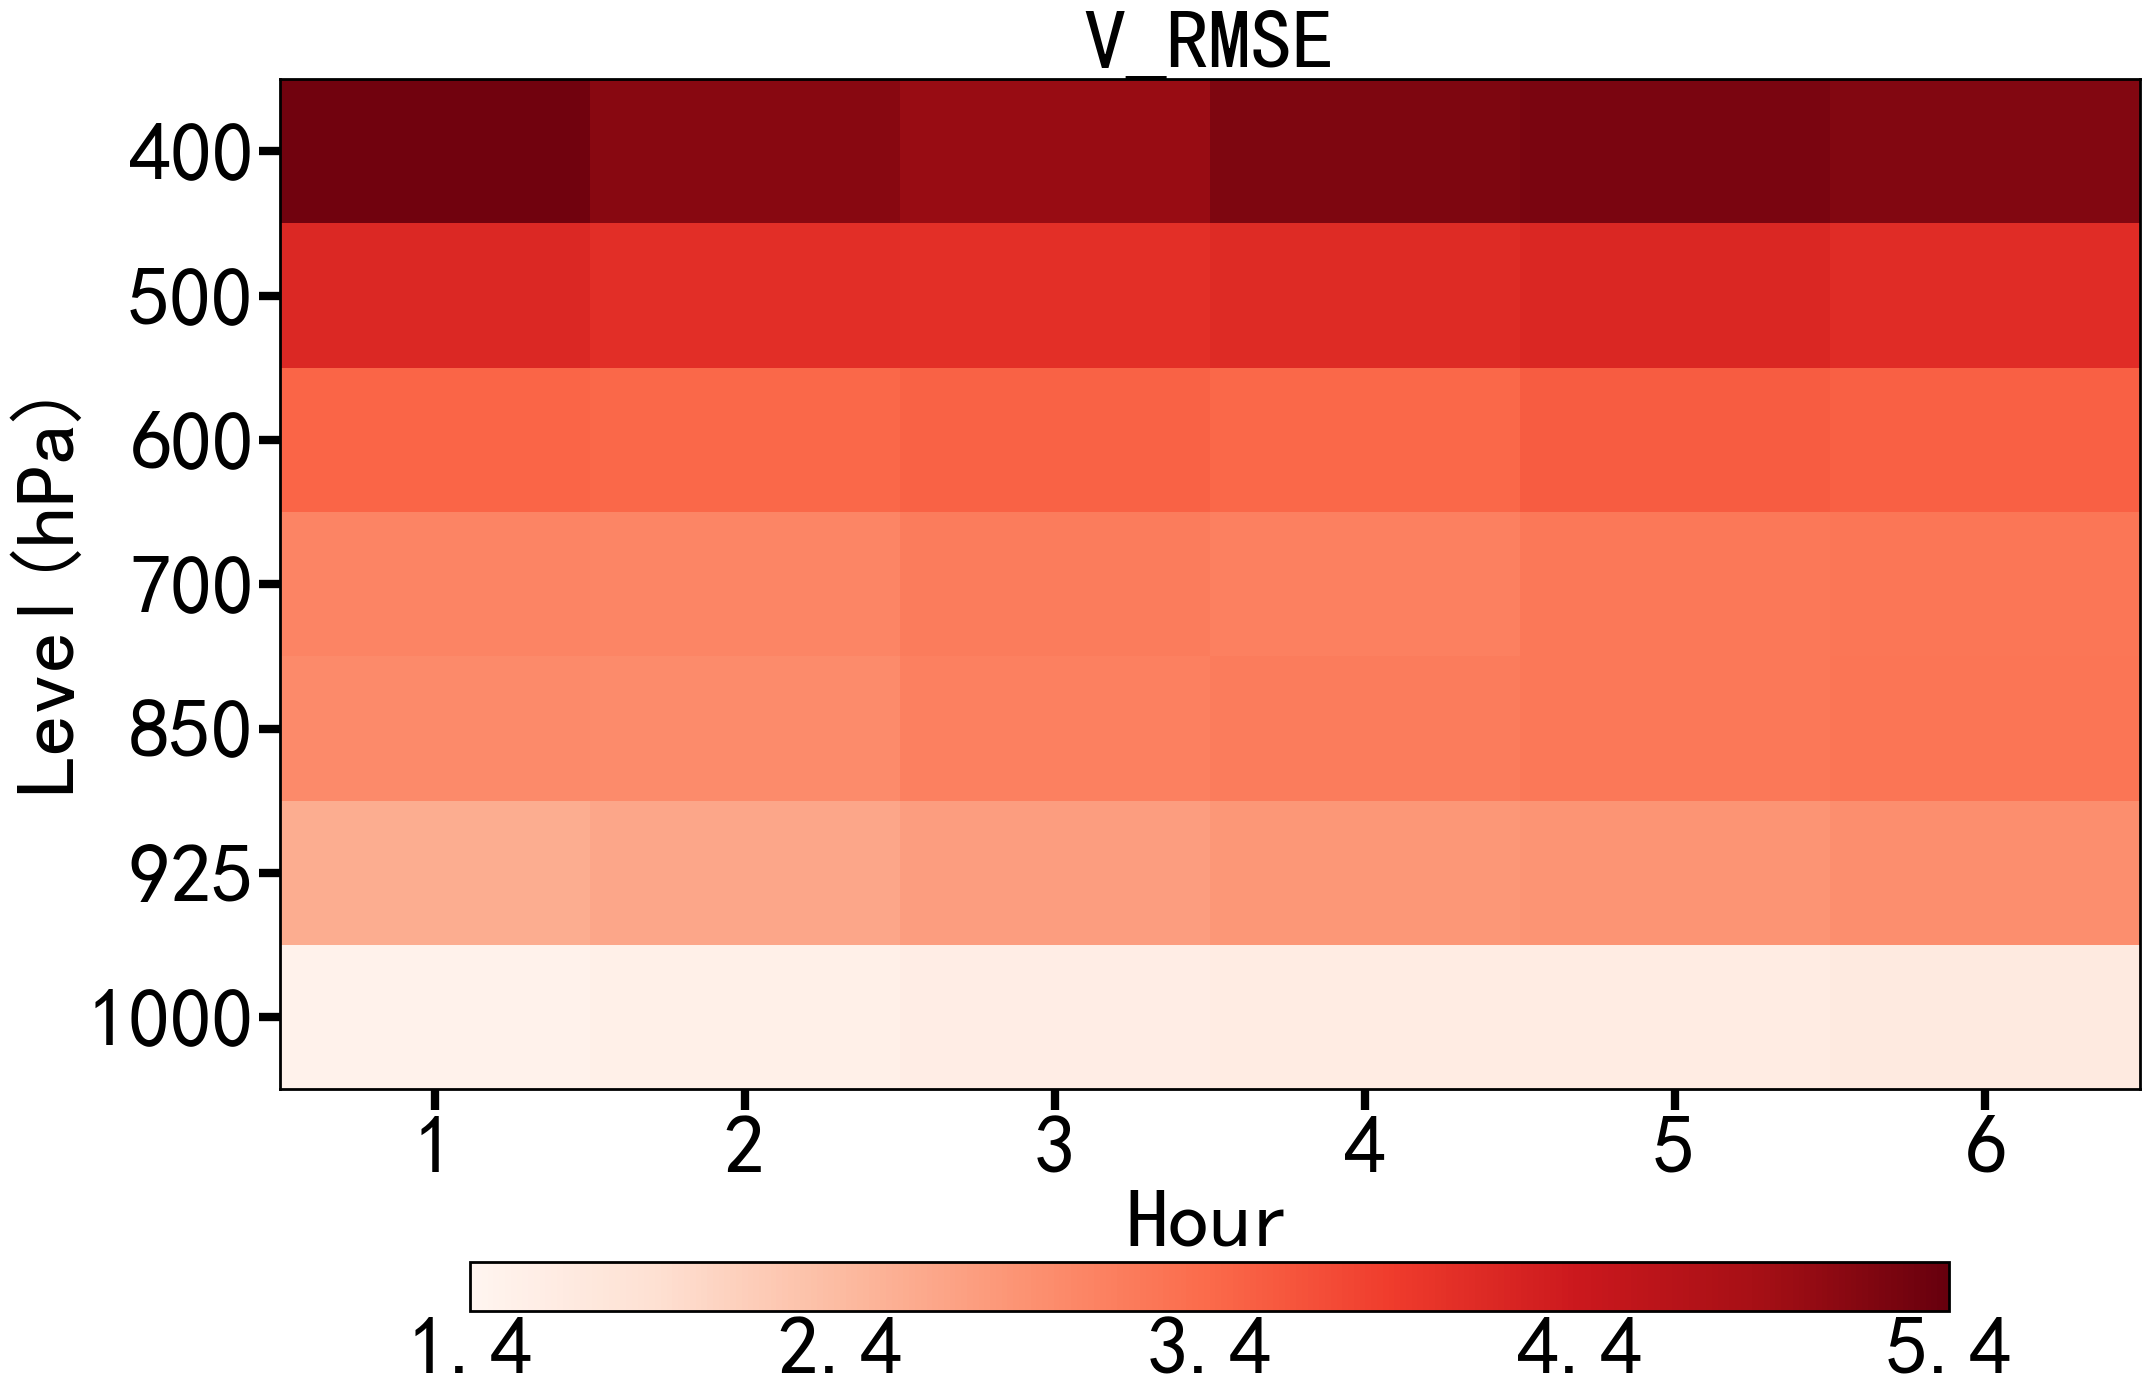

<Figure size 640x480 with 0 Axes>

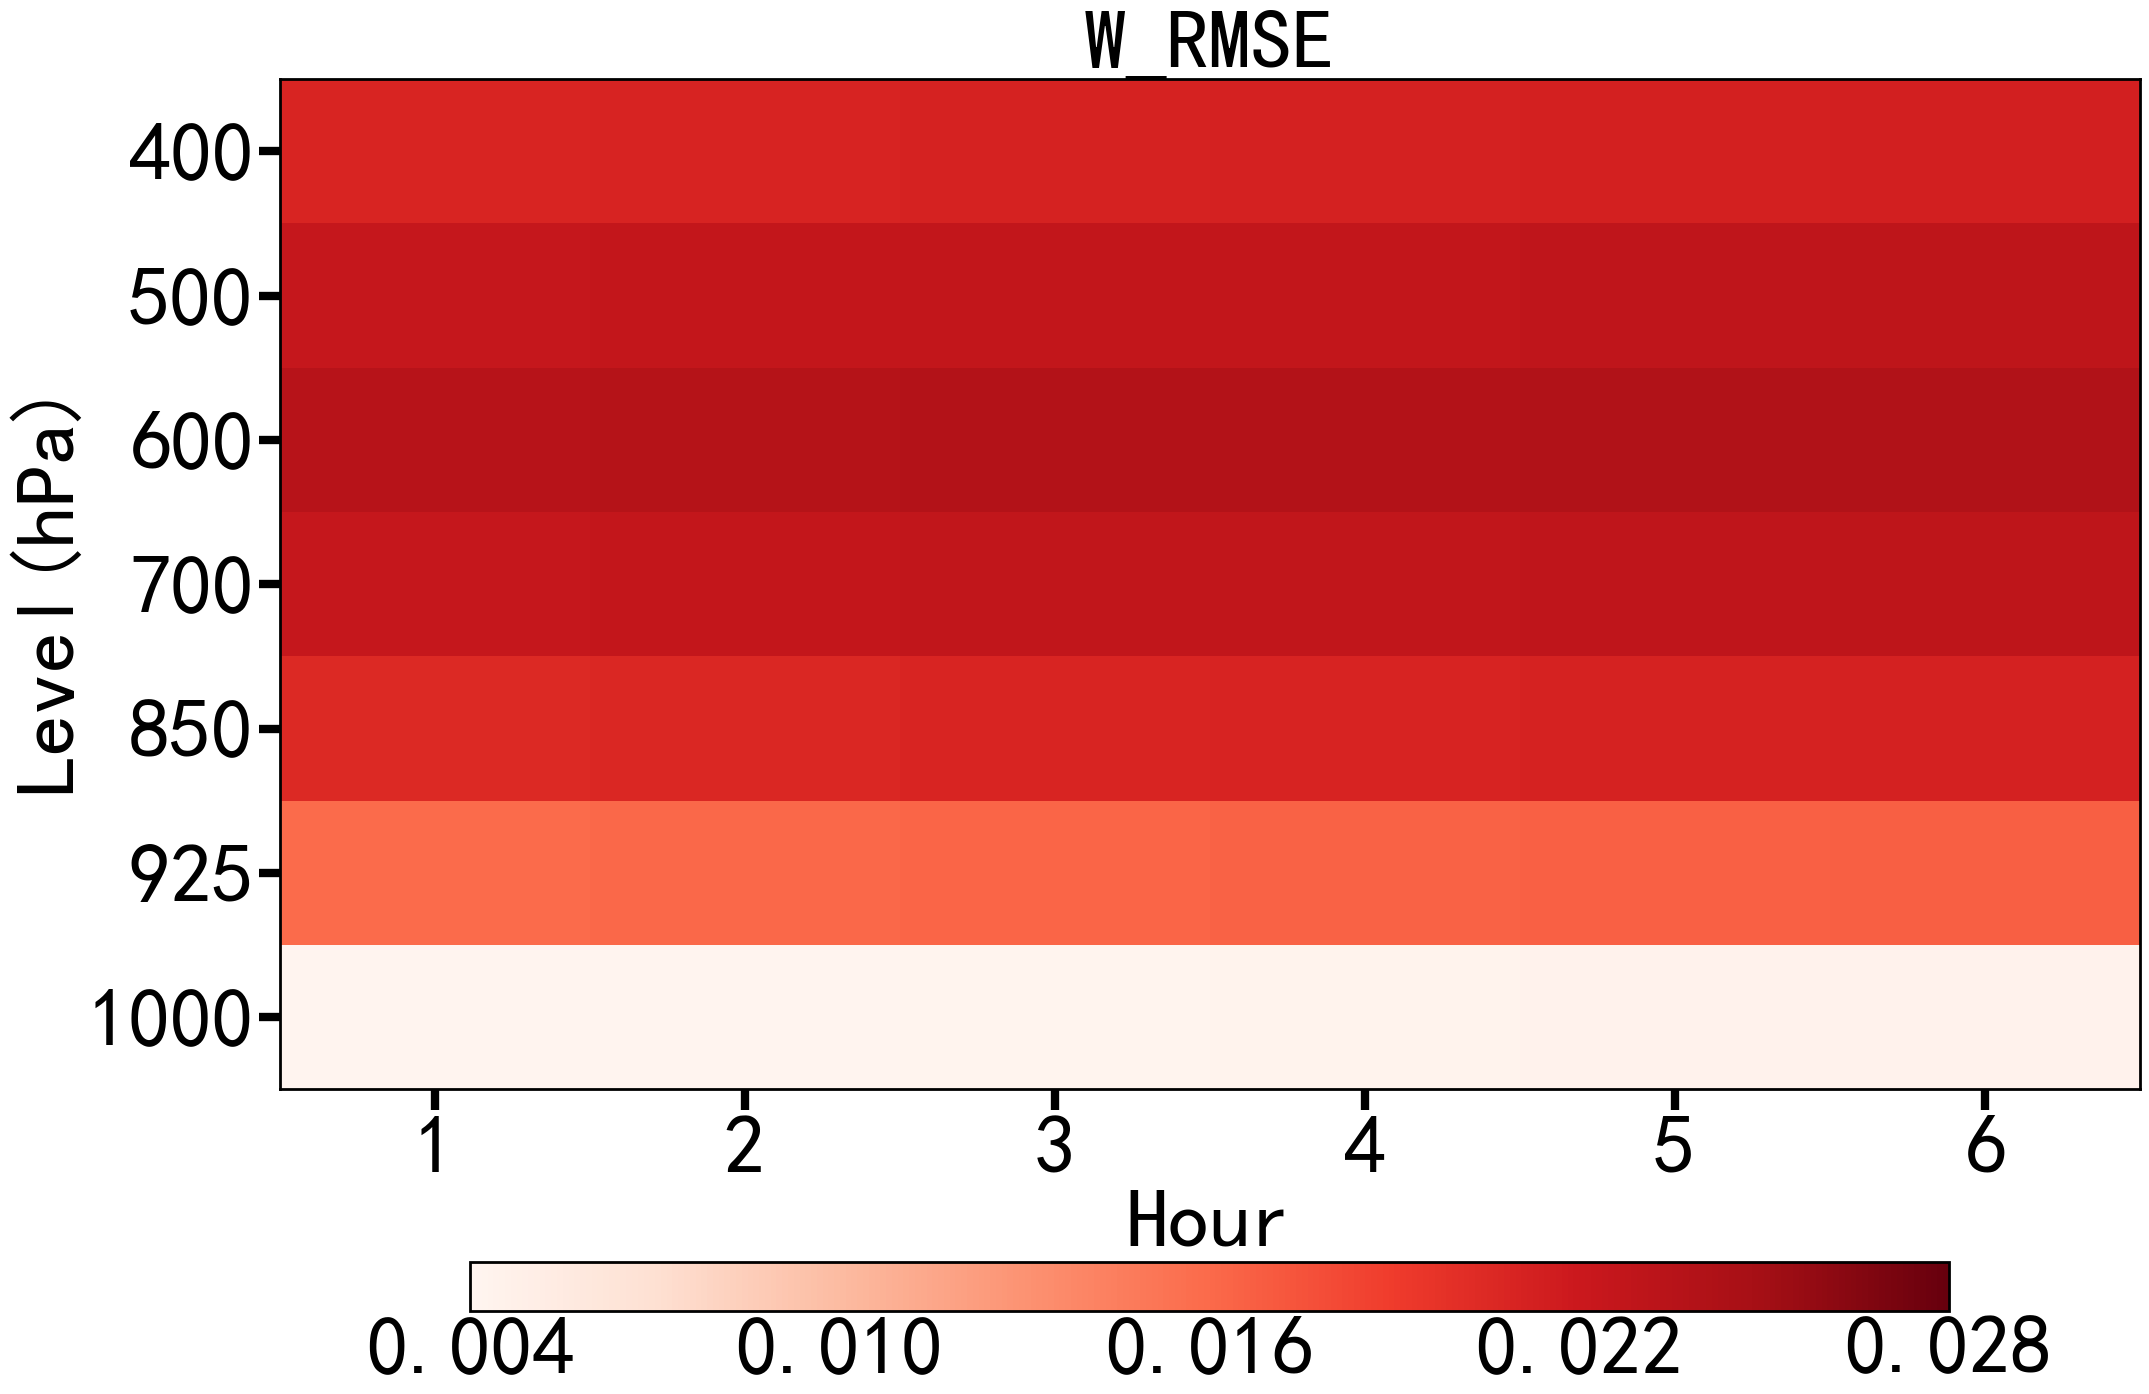

<Figure size 640x480 with 0 Axes>

In [27]:
import numpy as np
Auto_pcolormesh(x,y[::-1],np.array(u_rmse)[:,::-1].transpose(1,0),ifself_vmax_vmin='yes',selfvmax=6.4,selfvmin=1.4,xlabelname='Hour',ylabelname='Level(hPa)',title='U_RMSE',shadedcolor=None,valuemodel='+',xspace=1,yspace=1,labelsize=60,ifcolorbar='yes',ifsave='no',savename=None,dpi=600)
Auto_pcolormesh(x,y[::-1],np.array(v_rmse)[:,::-1].transpose(1,0),ifself_vmax_vmin='yes',selfvmax=5.4,selfvmin=1.4,xlabelname='Hour',ylabelname='Level(hPa)',title='V_RMSE',shadedcolor=None,valuemodel='+',xspace=1,yspace=1,labelsize=60,ifcolorbar='yes',ifsave='no',savename=None,dpi=600)
Auto_pcolormesh(x,y[::-1],np.array(w_rmse)[:,::-1].transpose(1,0),ifself_vmax_vmin='yes',selfvmax=0.028,selfvmin=0.004,xlabelname='Hour',ylabelname='Level(hPa)',title='W_RMSE',shadedcolor=None,valuemodel='+',xspace=1,yspace=1,labelsize=60,ifcolorbar='yes',ifsave='no',savename=None,dpi=600)

In [23]:
print(np.max(u_mae),np.min(u_mae))
print(np.max(v_mae),np.min(v_mae))
print(np.max(w_mae),np.min(w_mae))

4.84053753 1.10931205
4.0644474 1.12922504
0.01433534 0.00309643


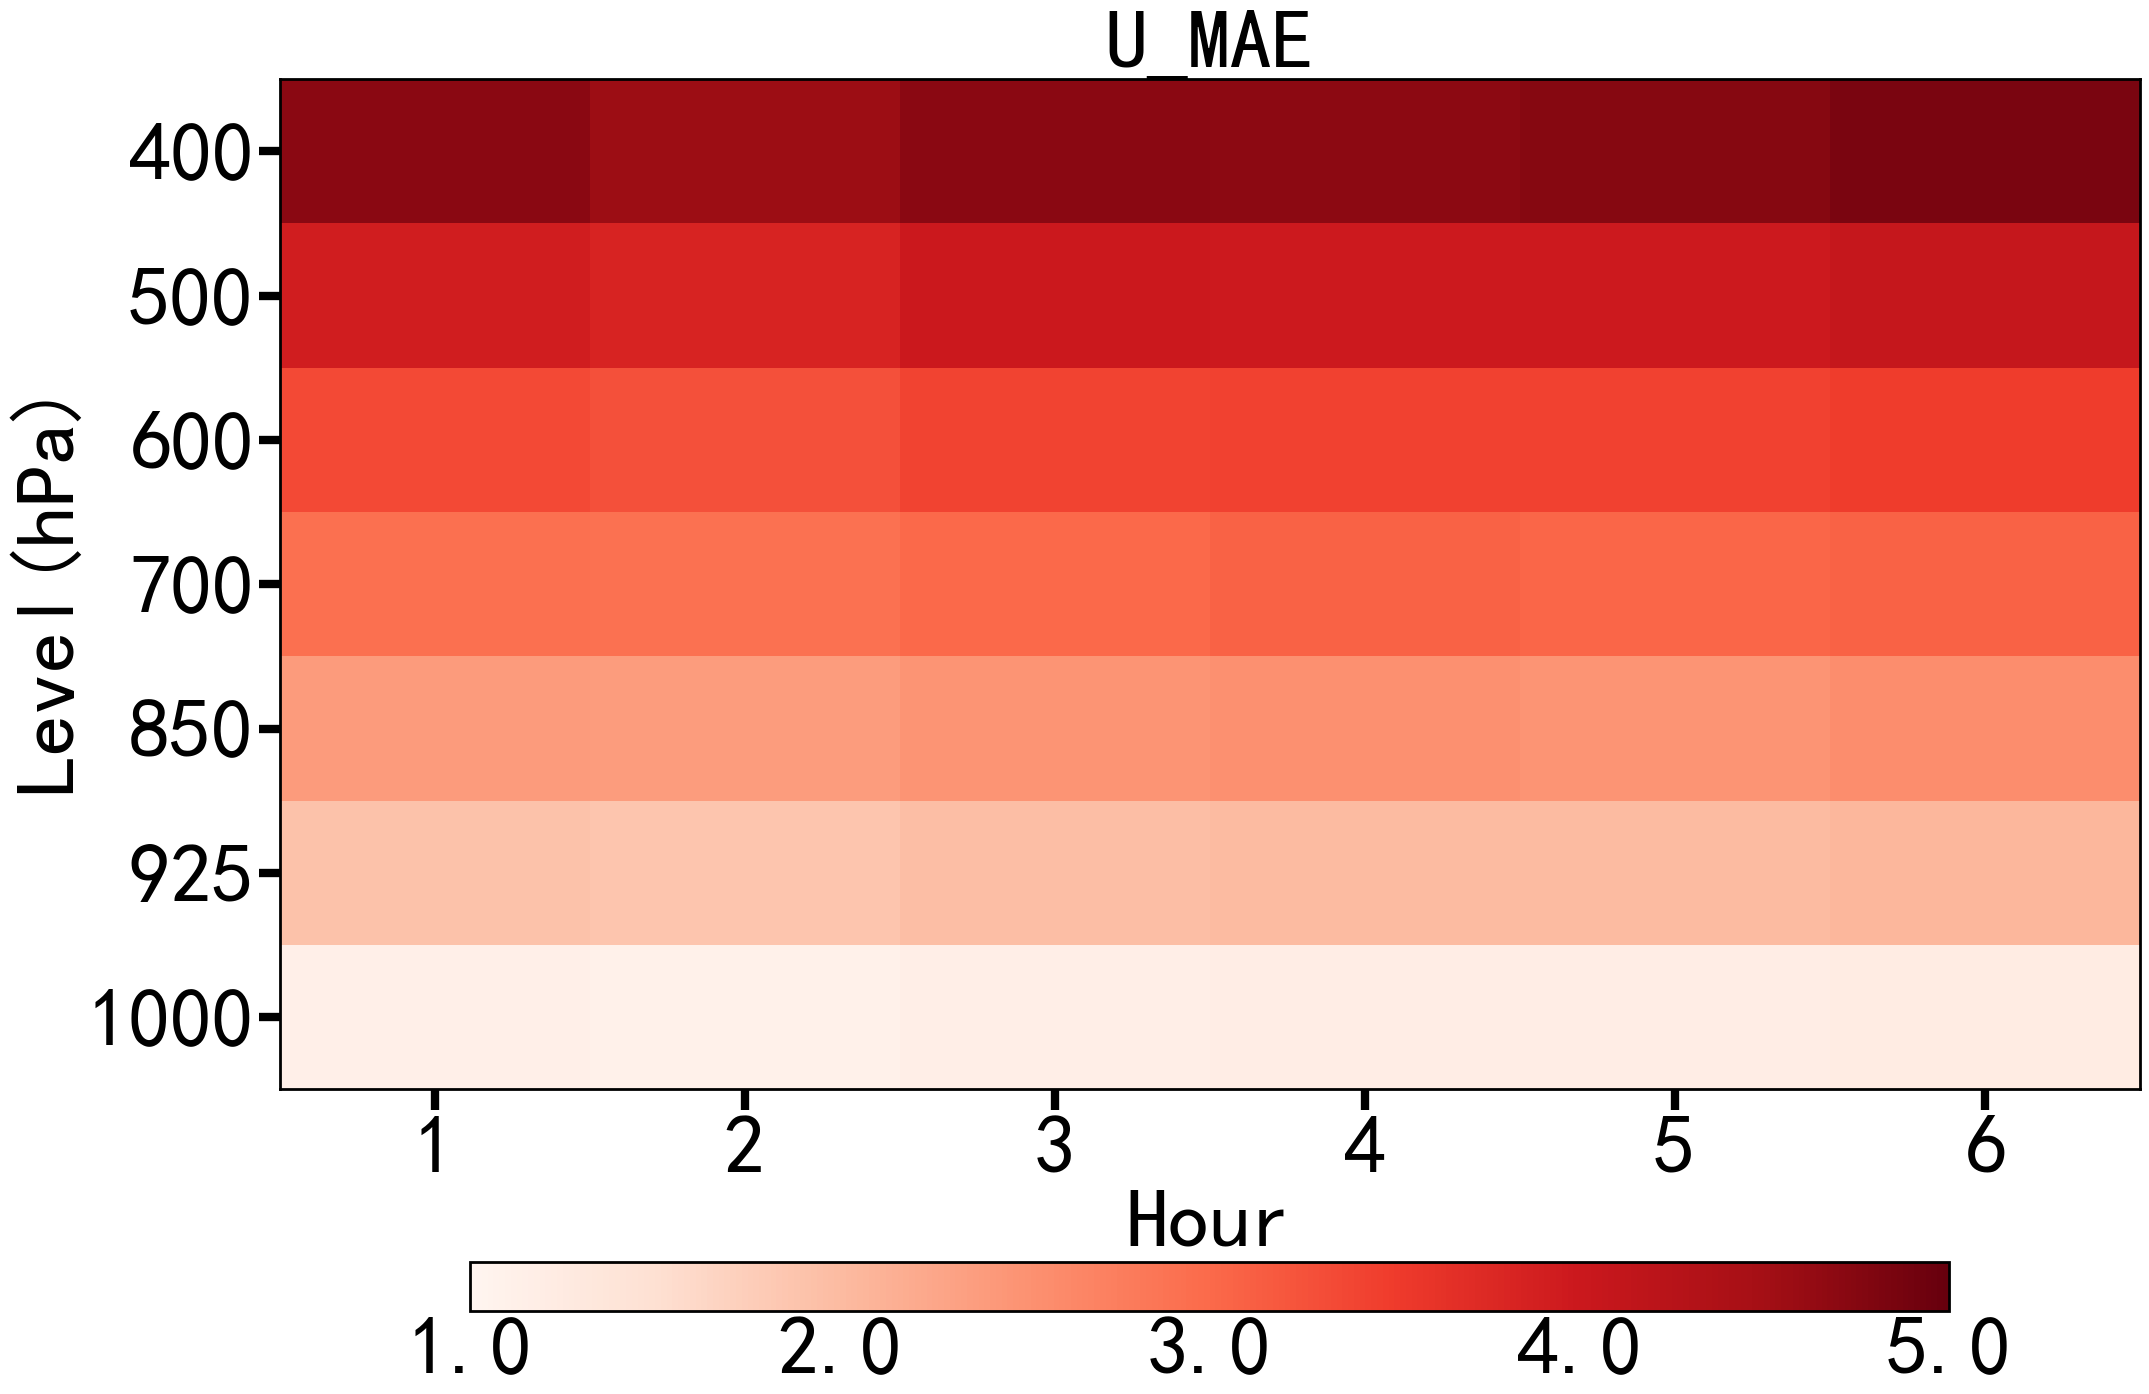

<Figure size 640x480 with 0 Axes>

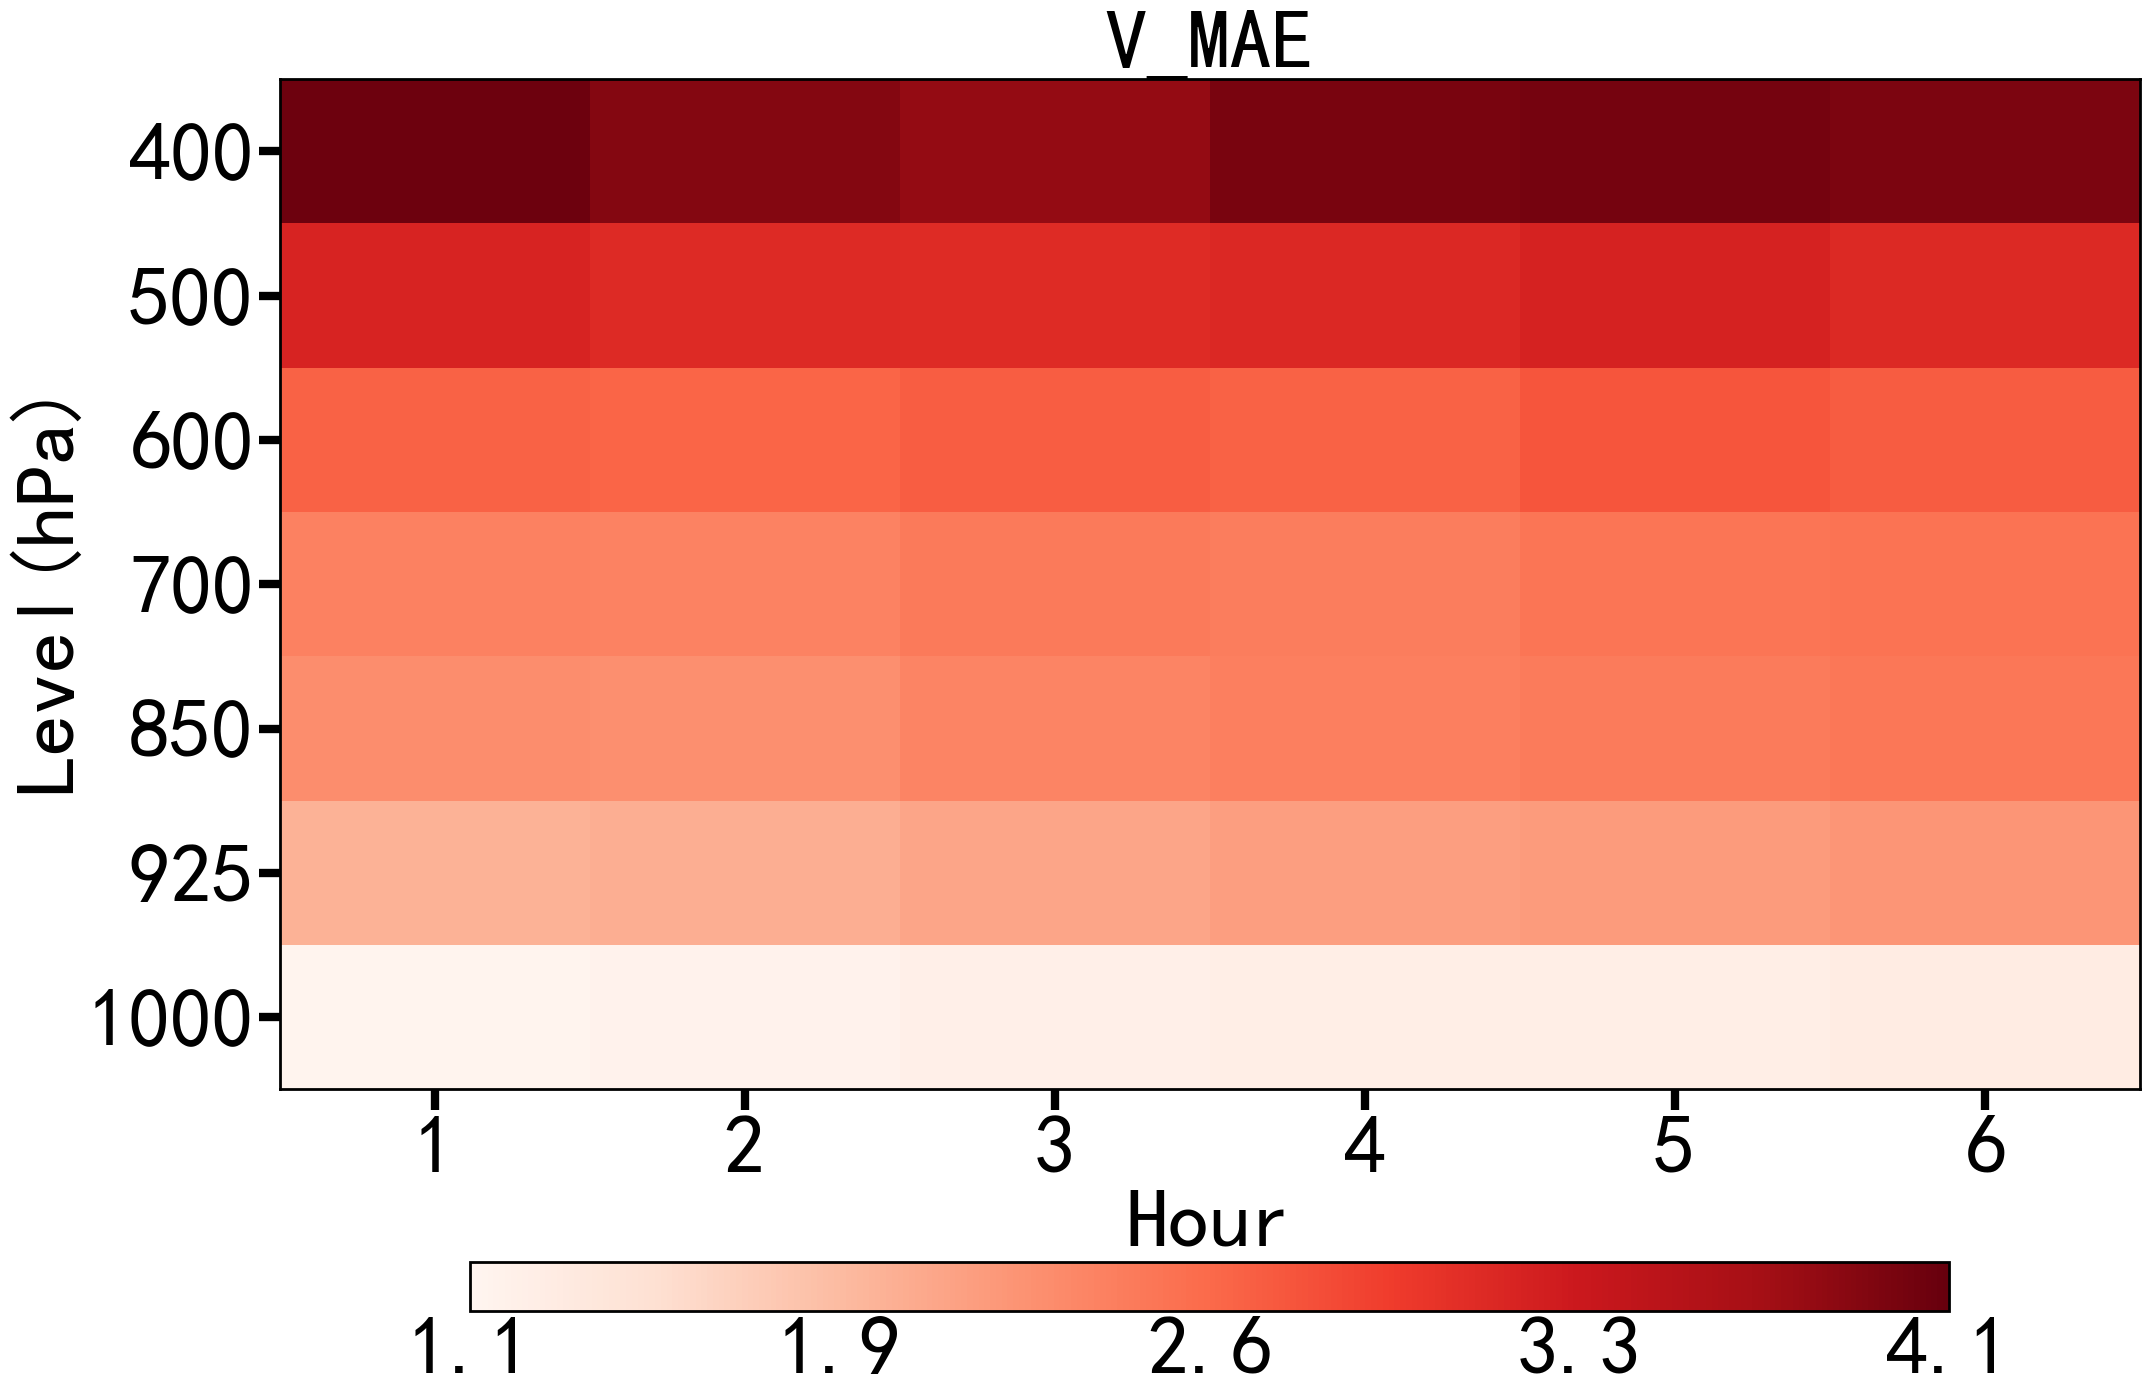

<Figure size 640x480 with 0 Axes>

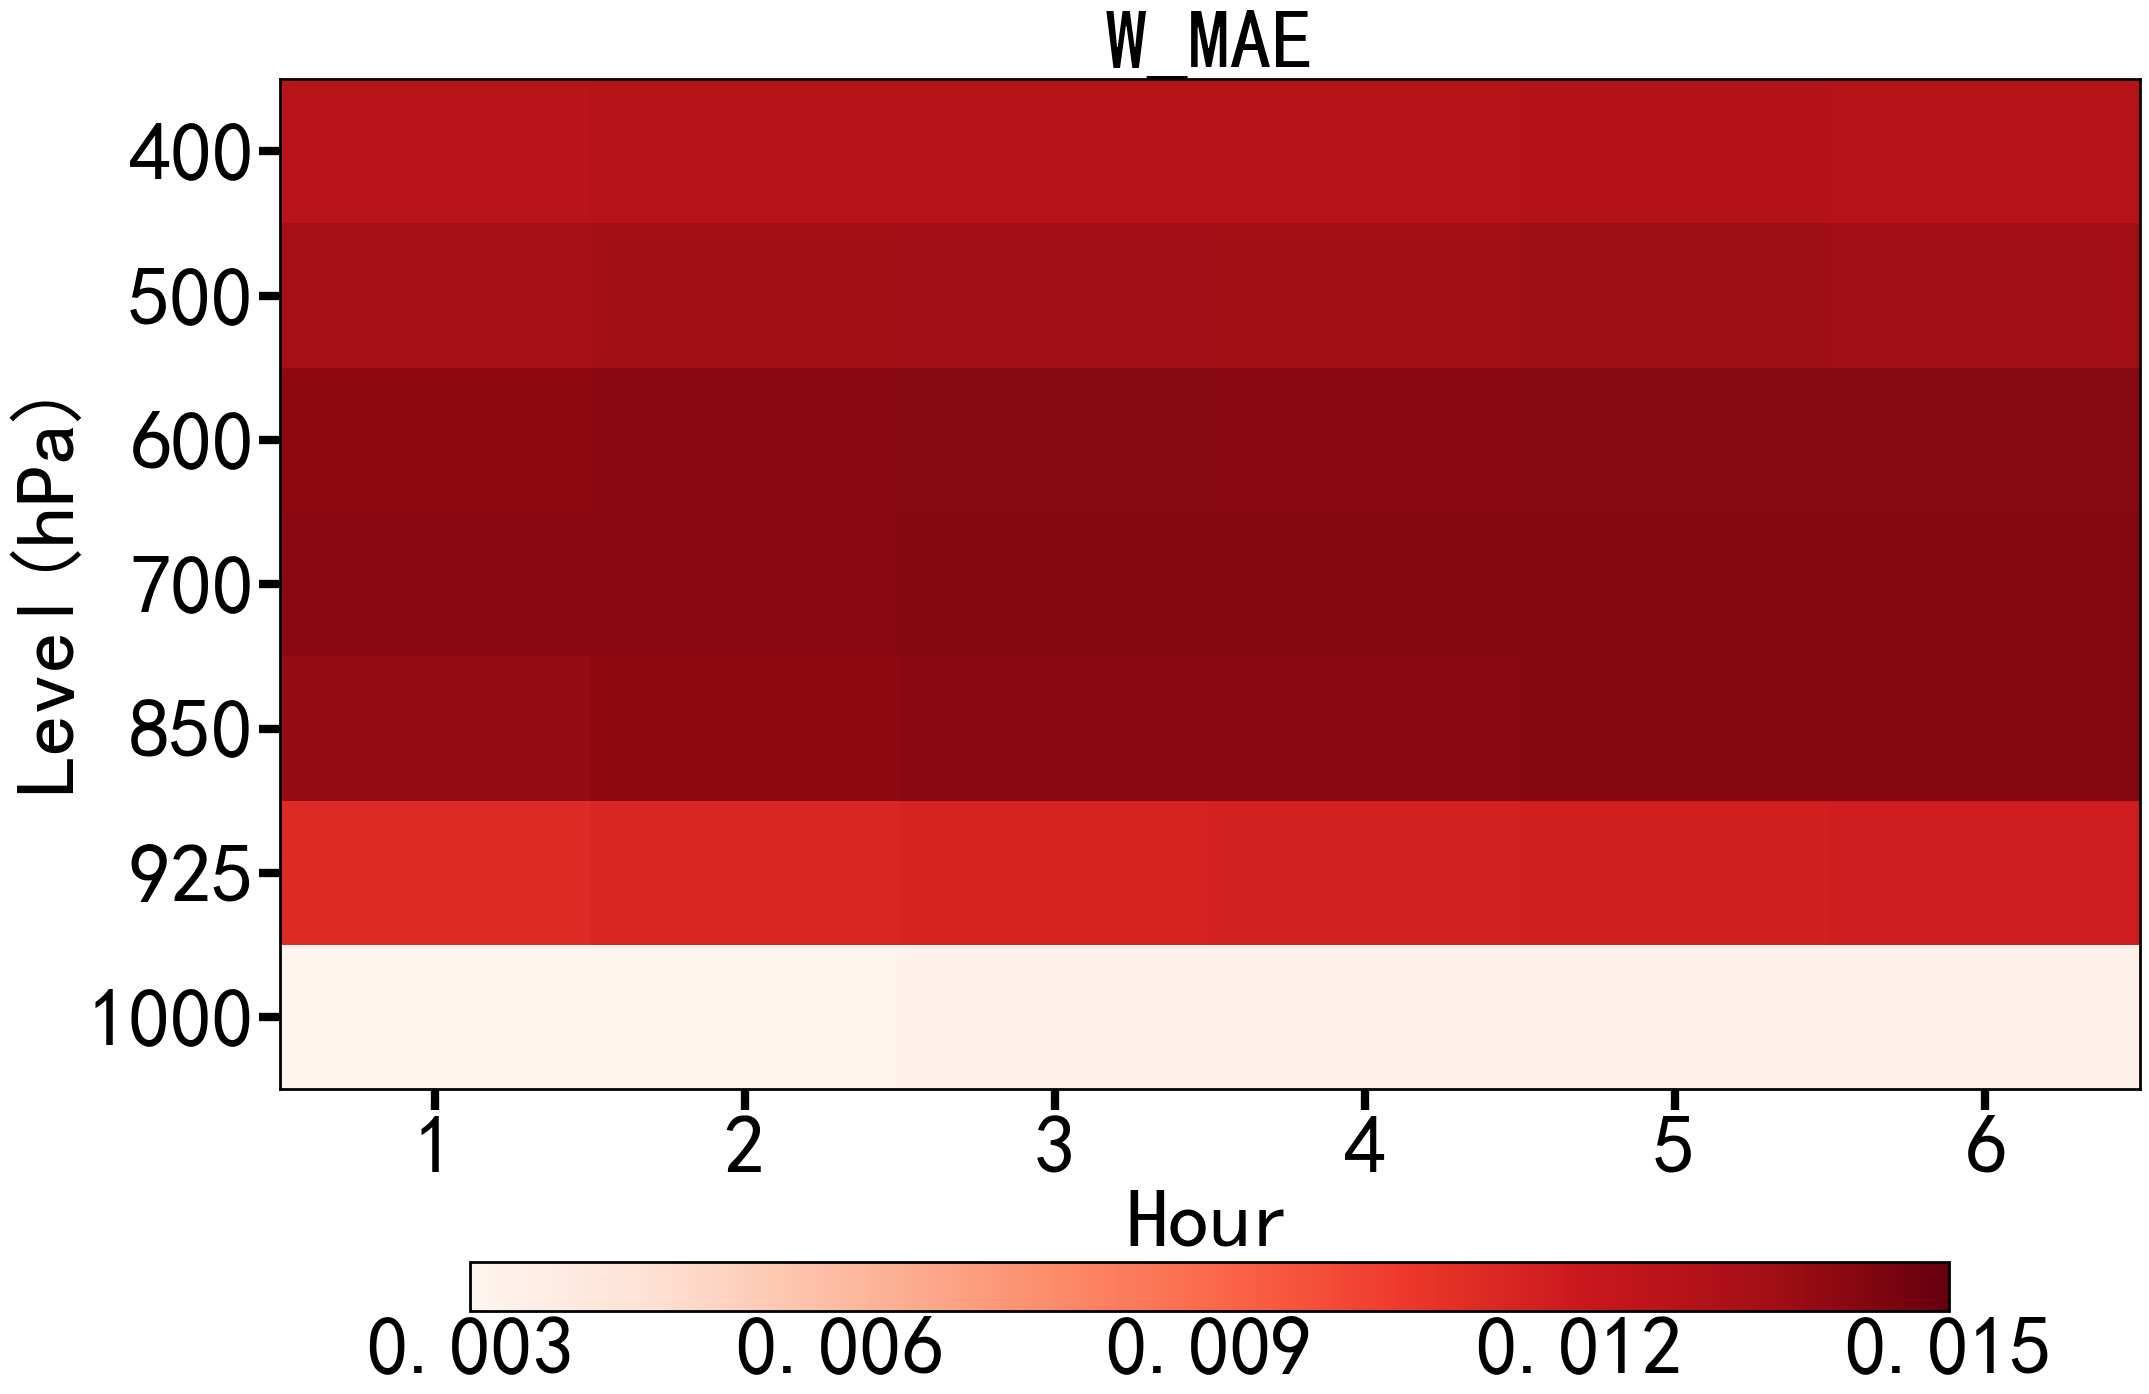

<Figure size 640x480 with 0 Axes>

In [24]:
import numpy as np
Auto_pcolormesh(x,y[::-1],np.array(u_mae)[:,::-1].transpose(1,0),ifself_vmax_vmin='yes',selfvmax=5.0,selfvmin=1.0,xlabelname='Hour',ylabelname='Level(hPa)',title='U_MAE',shadedcolor=None,valuemodel='+',xspace=1,yspace=1,labelsize=60,ifcolorbar='yes',ifsave='no',savename=None,dpi=600)
Auto_pcolormesh(x,y[::-1],np.array(v_mae)[:,::-1].transpose(1,0),ifself_vmax_vmin='yes',selfvmax=4.1,selfvmin=1.1,xlabelname='Hour',ylabelname='Level(hPa)',title='V_MAE',shadedcolor=None,valuemodel='+',xspace=1,yspace=1,labelsize=60,ifcolorbar='yes',ifsave='no',savename=None,dpi=600)
Auto_pcolormesh(x,y[::-1],np.array(w_mae)[:,::-1].transpose(1,0),ifself_vmax_vmin='yes',selfvmax=0.015,selfvmin=0.003,xlabelname='Hour',ylabelname='Level(hPa)',title='W_MAE',shadedcolor=None,valuemodel='+',xspace=1,yspace=1,labelsize=60,ifcolorbar='yes',ifsave='no',savename=None,dpi=600)

In [25]:
print(np.max(u_rmspe),np.min(u_rmspe))
print(np.max(v_rmspe),np.min(v_rmspe))
print(np.max(w_rmspe),np.min(w_rmspe))

0.09923053 0.0792728
0.12593022 0.06794447
0.07871983 0.04160256


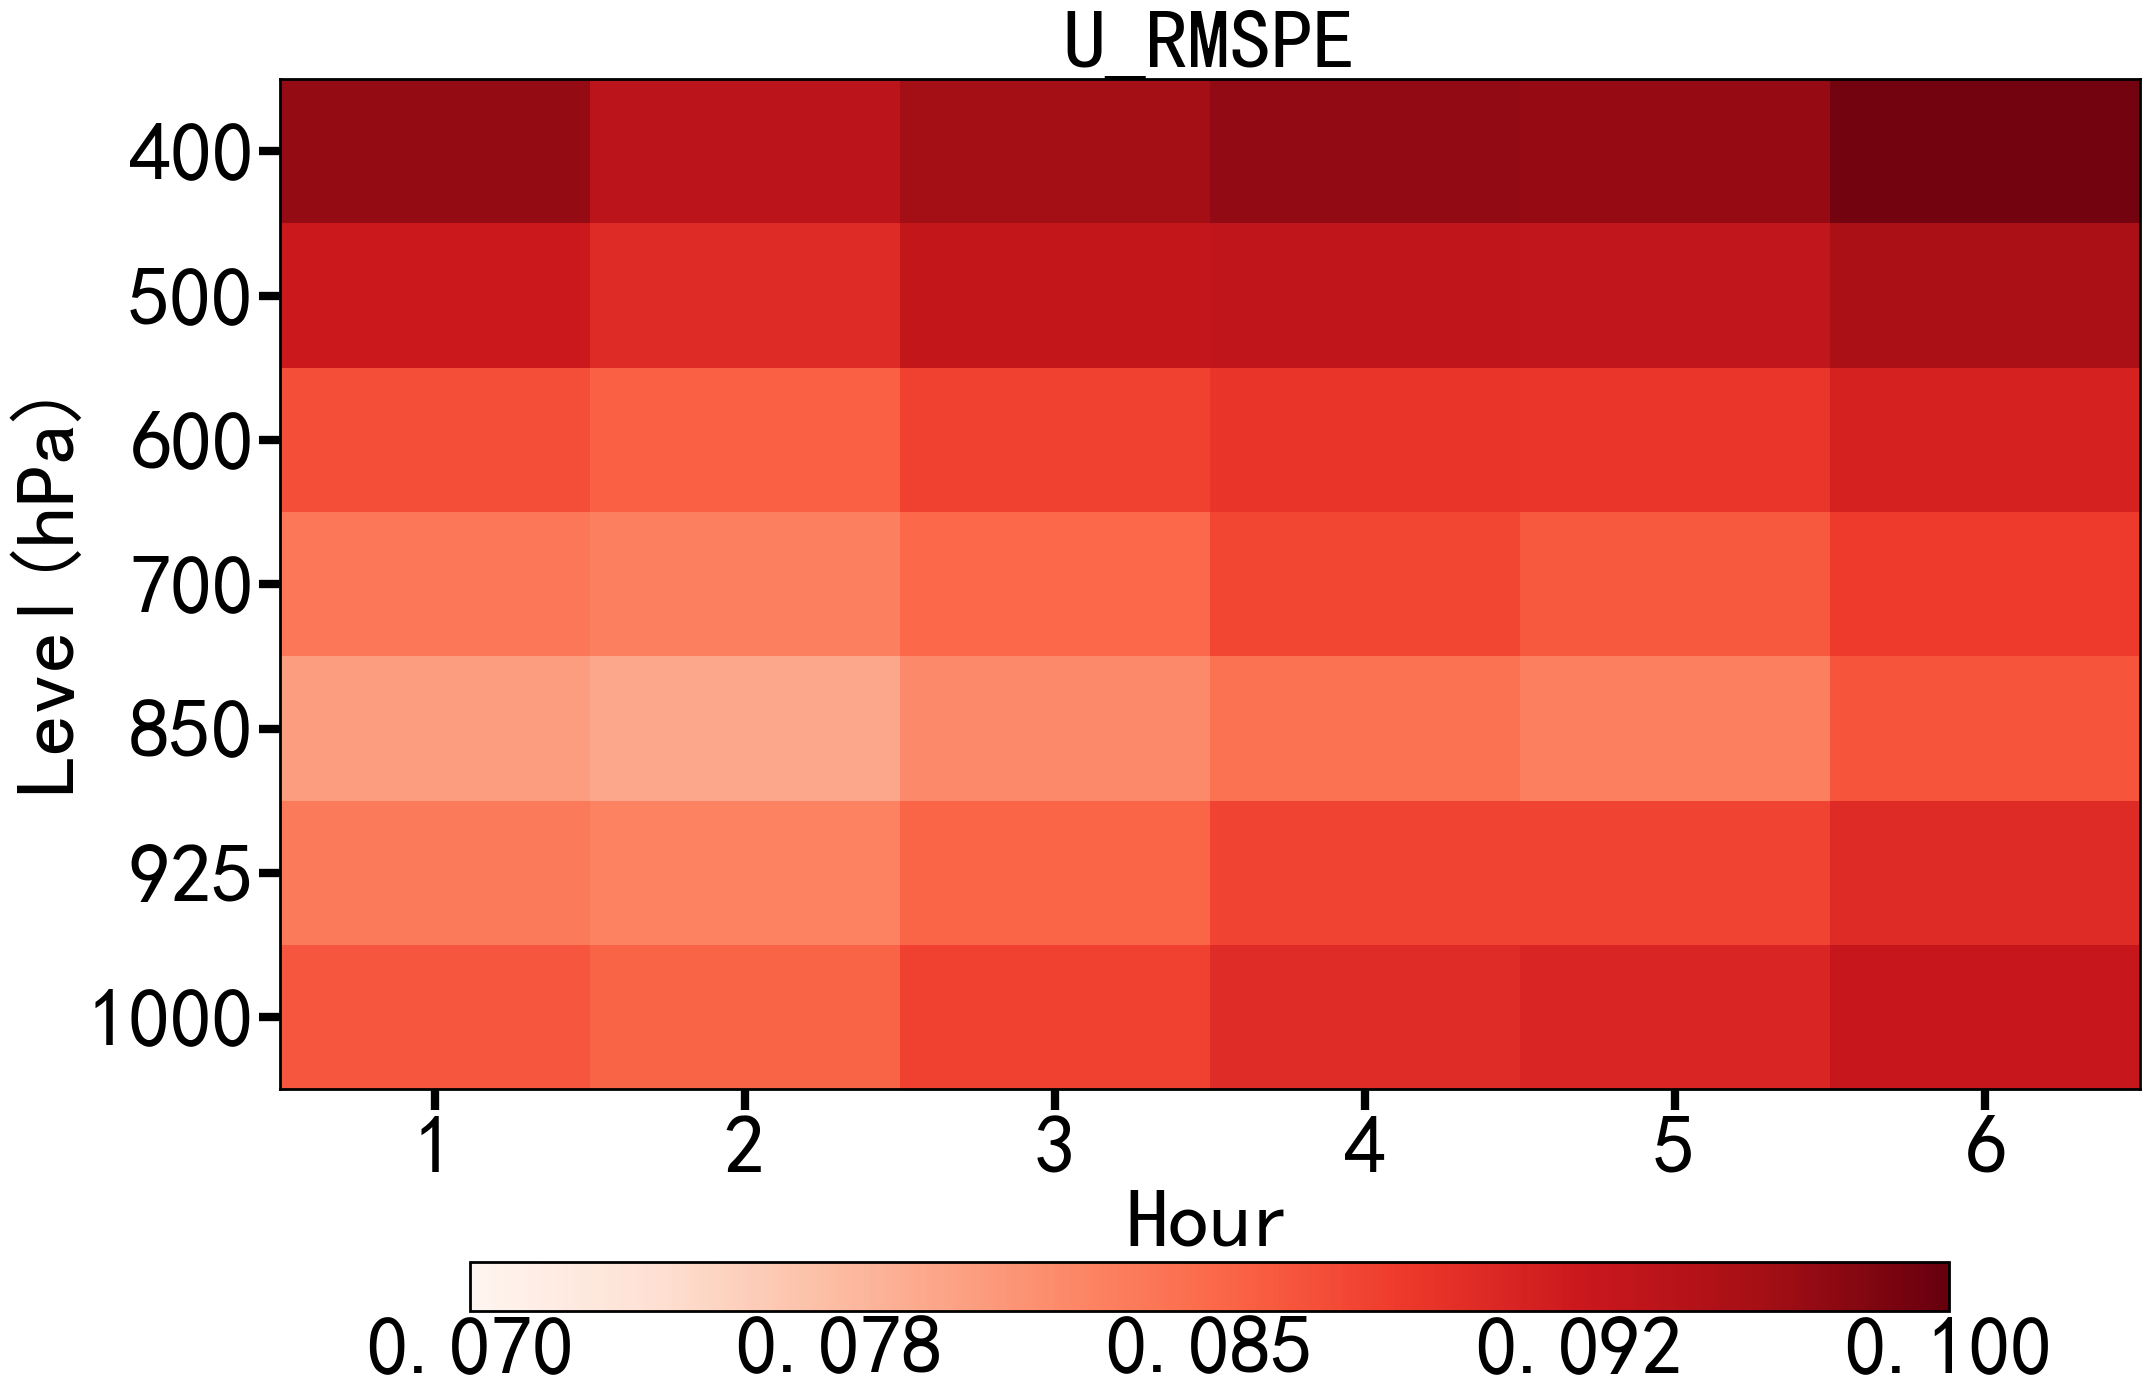

<Figure size 640x480 with 0 Axes>

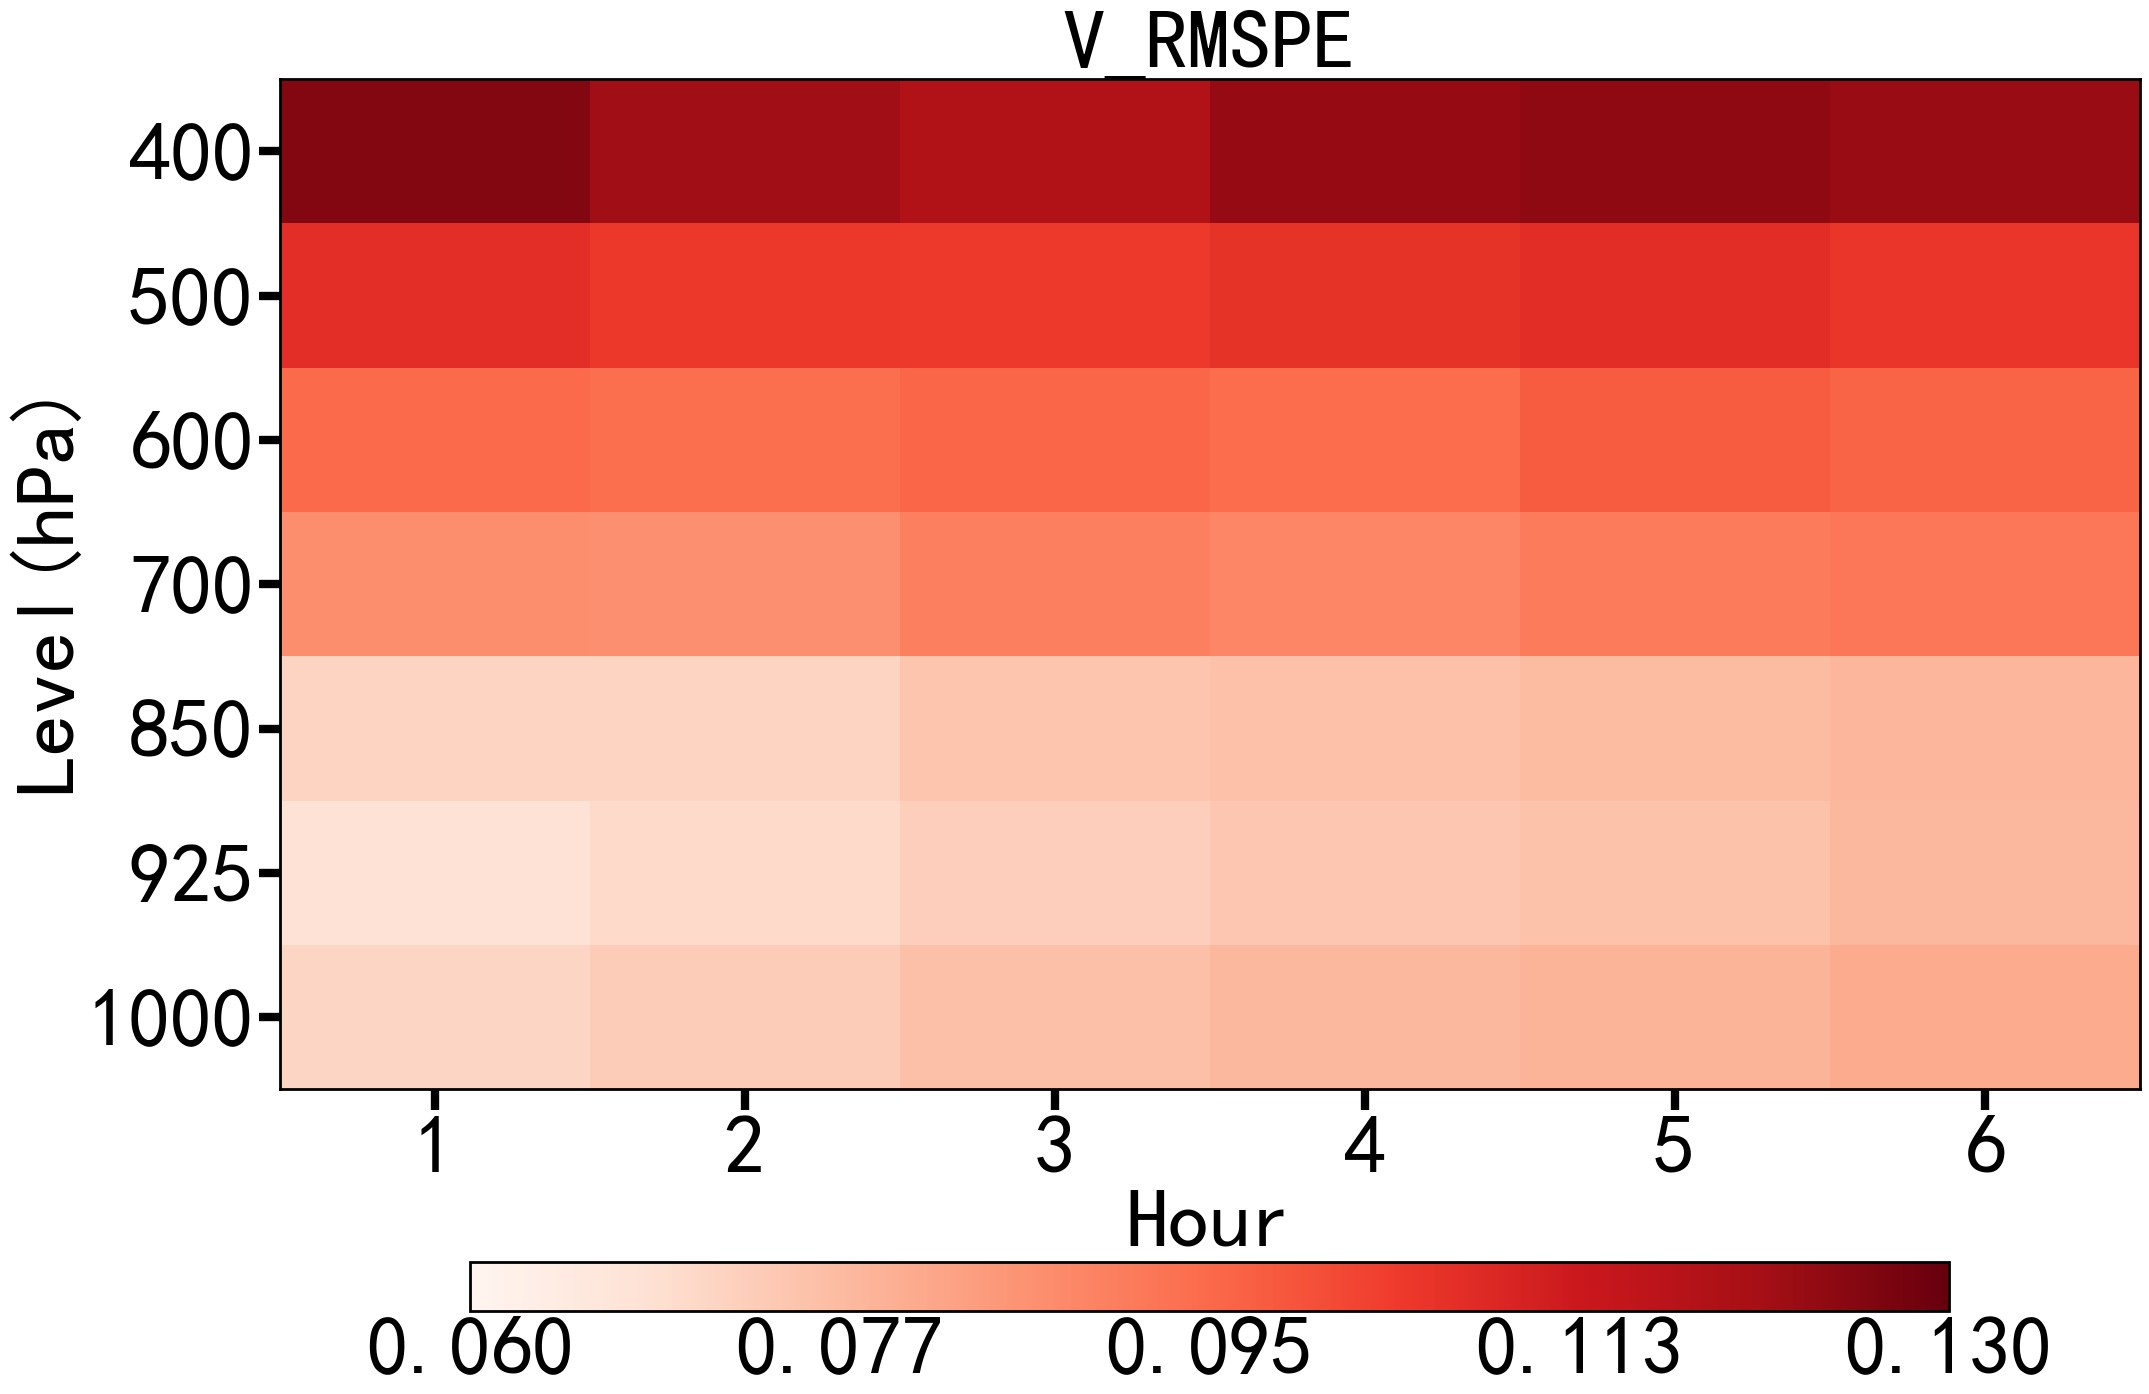

<Figure size 640x480 with 0 Axes>

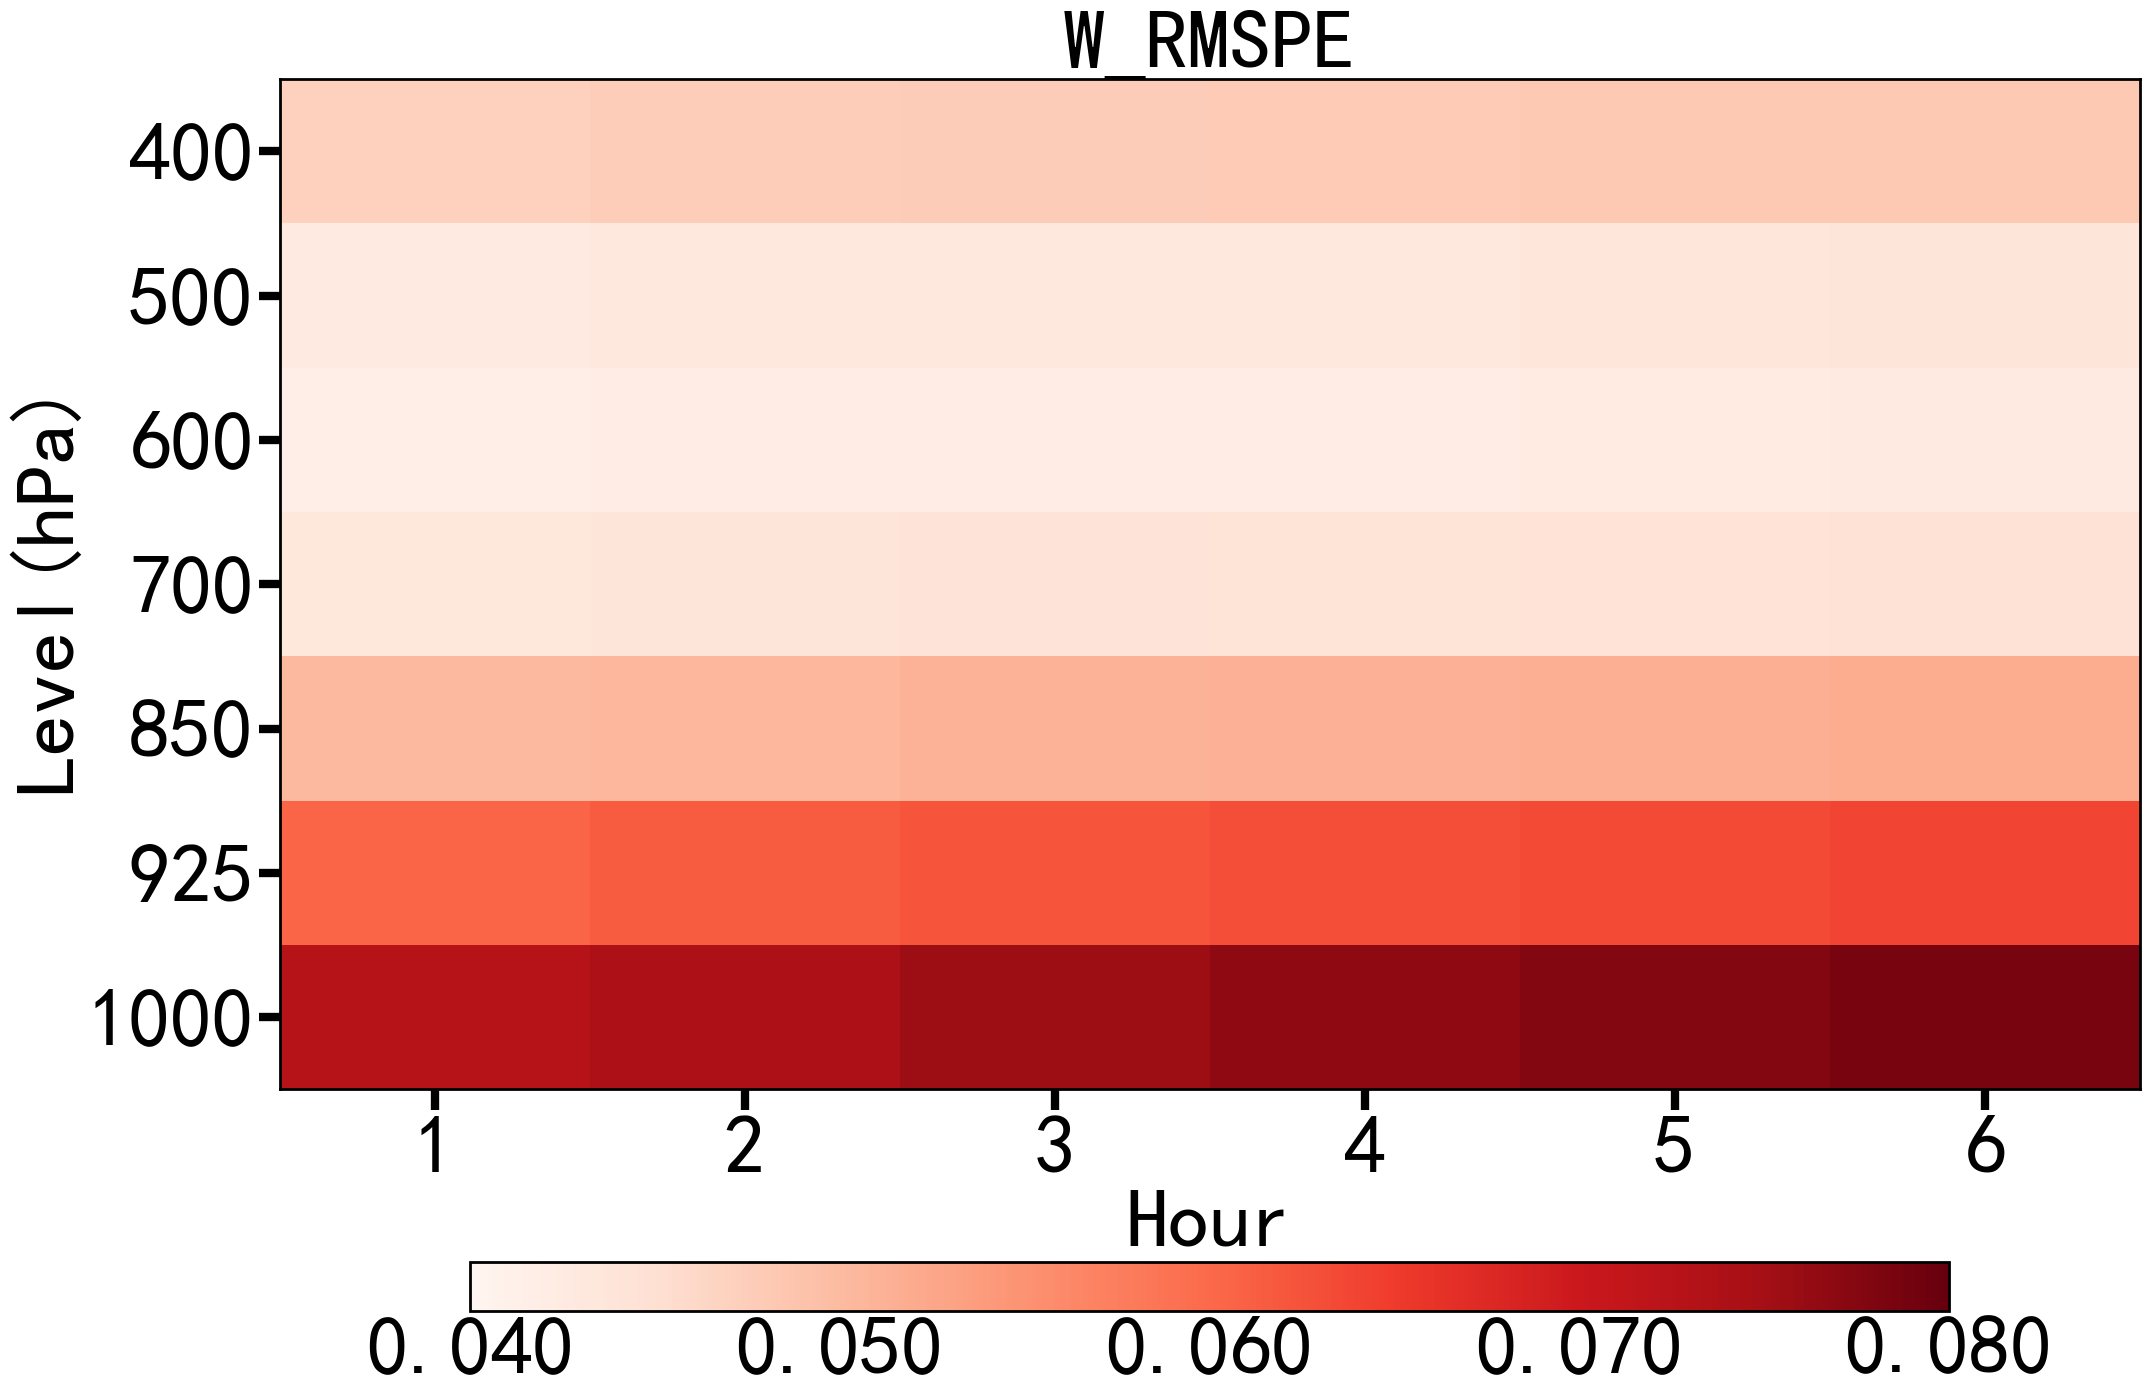

<Figure size 640x480 with 0 Axes>

In [26]:
import numpy as np
Auto_pcolormesh(x,y[::-1],np.array(u_rmspe)[:,::-1].transpose(1,0),ifself_vmax_vmin='yes',selfvmax=0.1,selfvmin=0.07,xlabelname='Hour',ylabelname='Level(hPa)',title='U_RMSPE',shadedcolor=None,valuemodel='+',xspace=1,yspace=1,labelsize=60,ifcolorbar='yes',ifsave='no',savename=None,dpi=600)
Auto_pcolormesh(x,y[::-1],np.array(v_rmspe)[:,::-1].transpose(1,0),ifself_vmax_vmin='yes',selfvmax=0.13,selfvmin=0.06,xlabelname='Hour',ylabelname='Level(hPa)',title='V_RMSPE',shadedcolor=None,valuemodel='+',xspace=1,yspace=1,labelsize=60,ifcolorbar='yes',ifsave='no',savename=None,dpi=600)
Auto_pcolormesh(x,y[::-1],np.array(w_rmspe)[:,::-1].transpose(1,0),ifself_vmax_vmin='yes',selfvmax=0.08,selfvmin=0.04,xlabelname='Hour',ylabelname='Level(hPa)',title='W_RMSPE',shadedcolor=None,valuemodel='+',xspace=1,yspace=1,labelsize=60,ifcolorbar='yes',ifsave='no',savename=None,dpi=600)

In [29]:
print(np.nanmean(u_rmspe),np.nanmean(v_rmspe),np.nanmean(w_rmspe))
print(np.nanmean(u_rmspe+v_rmspe+w_rmspe))

0.02381872547619048 0.02436710833333333 0.04182115595238096
0.03000232992063492
